# Mixing matrix convergence vs loop iteration, compared across `n_iter_pcg`

For each `blind_d0_DB_test_conv_nsub_6_*` run (a blind `d0`/dual-band fit, differing
only in `n_iter_pcg`, the number of PCG iterations per outer loop iteration),
`A_history` holds the fitted mixing matrix at every outer loop iteration.

The goal is to compare the runs against each other, per frequency bin, to see which
`n_iter_pcg` is best suited to reconstruct the mixing matrix: for each bin we overlay
the element's trajectory (and its residual to the truth) across all `n_iter_pcg`
values, so faster/better-converging settings are directly visible against slower/
worse ones.

Only `A_history`, `Atrue`, `nus_in`, `nus_out`, `comps_name`, `parameters` are loaded
from each file (`HDF5Dict.load_dict(..., keys=...)`) -- the map/TOD arrays are
skipped since they dominate file size and aren't needed here.

In [23]:
import glob

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from qubic.lib.Qhdf5 import HDF5Dict

In [24]:
folders = glob.glob("blind_d0_DB_test_conv_nsub_6_*")

hdf5 = HDF5Dict()
keys = ["A_history", "Atrue", "nus_in", "nus_out", "comps_name", "parameters"]
runs = []
for folder in folders:
    h5files = glob.glob(f"{folder}/Dict/test_*.h5")
    assert len(h5files) == 1, f"expected exactly one h5 file in {folder}/Dict, found {h5files}"
    run = hdf5.load_dict(h5files[0], keys=keys)
    run["n_iter_pcg"] = run["parameters"]["PCG"]["n_iter_pcg"]
    runs.append(run)

runs.sort(key=lambda r: r["n_iter_pcg"])
n_iters = np.array([r["n_iter_pcg"] for r in runs])

# The sky/instrument model is run-independent: sanity-check it actually is, in case
# some of these runs used a different config than the others.
for r in runs[1:]:
    assert np.allclose(r["nus_out"], runs[0]["nus_out"])
    assert np.allclose(r["nus_in"], runs[0]["nus_in"])
    assert np.allclose(r["Atrue"], runs[0]["Atrue"])
    assert r["parameters"]["Foregrounds"]["bin_mixing_matrix"] == runs[0]["parameters"]["Foregrounds"]["bin_mixing_matrix"]

comp_names = [c.decode() if isinstance(c, bytes) else c for c in runs[0]["comps_name"]]
n_bins = runs[0]["parameters"]["Foregrounds"]["bin_mixing_matrix"]
nus_in = runs[0]["nus_in"]
nus_out = runs[0]["nus_out"]

# BlindMM.update() computes fsub_out from the QUBIC-only sub-band count
# (joint_out.qubic.nsub, i.e. params["QUBIC"]["nsub_out"]), NOT from nus_out.size:
# nus_out appends external Planck channels after the nsub_out QUBIC ones, and the
# blind fit's n_bins bins only ever span those first nsub_out channels (see
# blindMM.py: `fsub_out = joint_out.qubic.nsub // n_bins`). Matching that exactly
# here matters -- using nus_out.size instead would silently mix in the (untouched)
# Planck channels and misrepresent which bins are actually being reconstructed.
nsub_qubic = runs[0]["parameters"]["QUBIC"]["nsub_out"]
fsub_out = nsub_qubic // n_bins
nus_qubic = nus_out[:nsub_qubic]

print(f"Found {len(runs)} runs, n_iter_pcg = {list(n_iters)}")
print(f"comps={comp_names}  bin_mixing_matrix={n_bins}  nsub_out(QUBIC)={nsub_qubic}  fsub_out={fsub_out}")

Found 9 runs, n_iter_pcg = [5, 7, 10, 12, 15, 17, 20, 25, 30]
comps=['CMB', 'Dust']  bin_mixing_matrix=6  nsub_out(QUBIC)=18  fsub_out=3


In [25]:
def _bin_by_freq(arr, n_bins, fsub_out):
    """Average `arr` over each block of `fsub_out` consecutive output frequencies.

    Same binning as BlindMM._bin_by_freq: the blind fit only has `n_bins` independent
    values, each shared across `fsub_out` frequencies.
    """
    return np.array([arr[i * fsub_out : (i + 1) * fsub_out].mean(axis=0) for i in range(n_bins)])


nus_binned = _bin_by_freq(nus_qubic, n_bins, fsub_out)

# Atrue is defined on the nus_in grid (finer QUBIC sampling), A on the coarser
# nus_qubic grid. The underlying SED is a smooth, densely-sampled function of
# frequency, so we interpolate it onto nus_qubic before applying the same
# bin-averaging as A -- this compares two piecewise-constant curves over identical
# bins instead of a piecewise-constant fit against a smooth truth, which would show
# spurious binning "residual".
order = np.argsort(nus_in)
truth_at_out = np.array(
    [np.interp(nus_qubic, nus_in[order], runs[0]["Atrue"][order, ic]) for ic in range(len(comp_names))]
).T
truth_binned = _bin_by_freq(truth_at_out, n_bins, fsub_out)  # (n_bins, ncomp)

# Full loop-iteration history of A, restricted to the QUBIC channels BlindMM actually
# fits and binned the same way as above. All runs share the same n_iter_loop, so this
# stacks cleanly into one array indexed by (run, loop iteration).
n_loop_iters = np.array([r["A_history"].shape[0] for r in runs])
assert np.all(n_loop_iters == n_loop_iters[0]), f"runs have different n_iter_loop: {dict(zip(n_iters, n_loop_iters))}"
loop_iters = np.arange(n_loop_iters[0])

A_history_stack = np.array(
    [[_bin_by_freq(snap[:nsub_qubic], n_bins, fsub_out) for snap in r["A_history"]] for r in runs]
)  # (n_runs, n_loop_iter, n_bins, ncomp)

# Component 0 (CMB) has a mixing-matrix element fixed to 1 by construction in this
# blind fit -- only the other components are actually reconstructed.
free_comps = list(range(1, len(comp_names)))

## Mixing matrix elements and residual vs loop iteration, compared across `n_iter_pcg`

All `n_bins` bins here are the ones `BlindMM` actually fits (they span the first
`nsub_out` QUBIC channels only; the appended Planck channels aren't part of the blind
fit's bins at all and are excluded above via `nus_qubic`/`fsub_out`).

One small-multiples grid per figure, one subplot per frequency bin. Within each
subplot, every `n_iter_pcg` run is overlaid (colored dark-to-light by increasing
`n_iter_pcg`), so the runs can be compared directly per bin: which setting converges
fastest, and which one reaches the lowest residual.

First figure: the mixing matrix element itself (dashed black line = truth). Second
figure: relative residual to the truth, `|A - Atrue| / Atrue`, log scale.

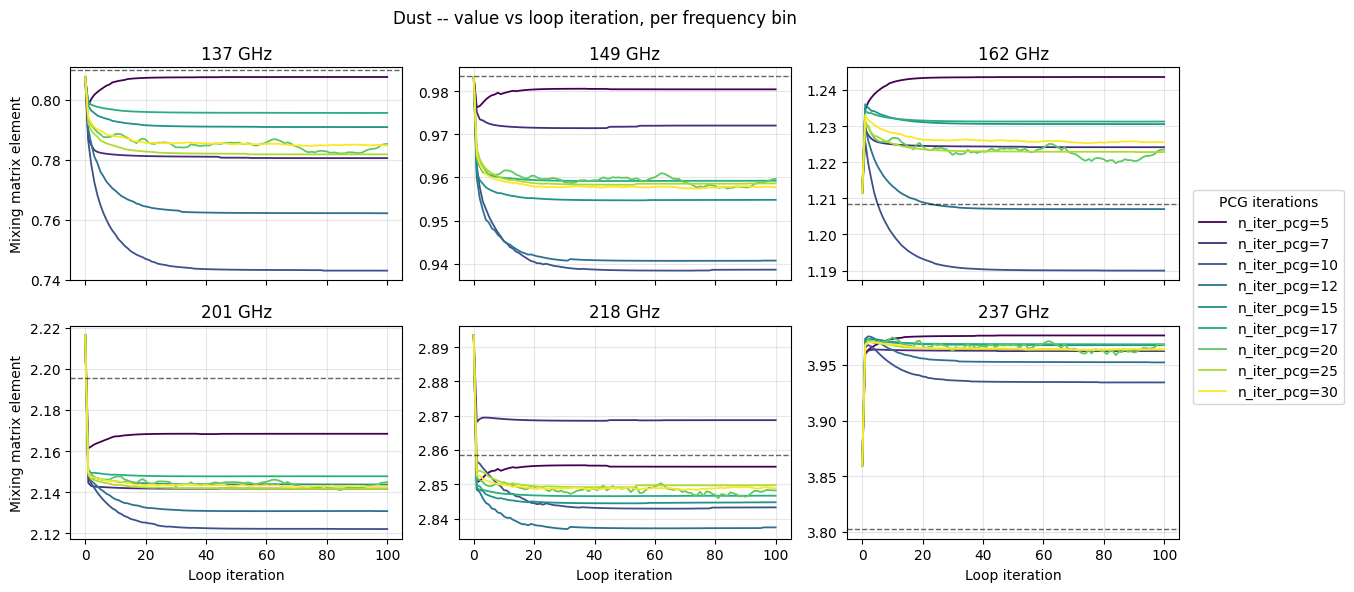

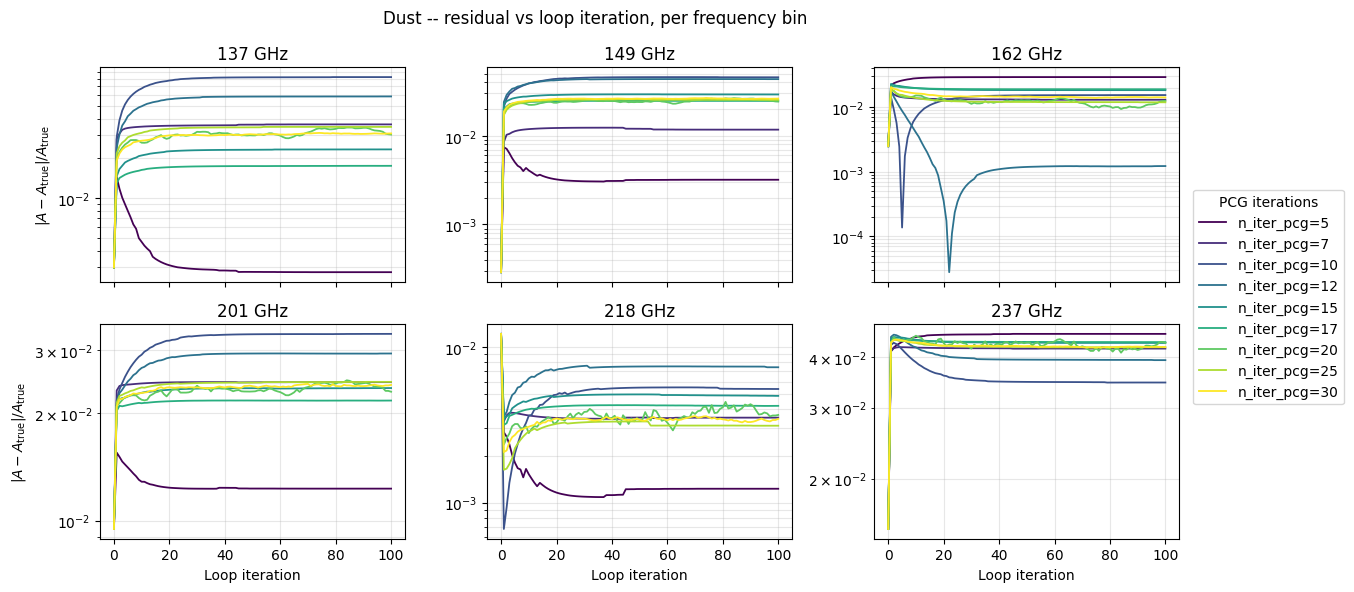

In [26]:
n_cols = 3
n_rows = int(np.ceil(n_bins / n_cols))
cmap = plt.get_cmap("viridis", len(runs))

for ic in free_comps:
    for quantity, ylabel, log_scale in [
        ("value", "Mixing matrix element", False),
        ("residual", r"$|A - A_{\mathrm{true}}| / A_{\mathrm{true}}$", True),
    ]:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, squeeze=False)
        axes = axes.ravel()

        for ib in range(n_bins):
            ax = axes[ib]
            for irun in range(len(runs)):
                trajectory = A_history_stack[irun, :, ib, ic]
                if quantity == "value":
                    y = trajectory
                else:
                    y = np.abs(trajectory - truth_binned[ib, ic]) / truth_binned[ib, ic]
                ax.plot(loop_iters, y, color=cmap(irun), lw=1.3, label=f"n_iter_pcg={n_iters[irun]}")

            if quantity == "value":
                ax.axhline(truth_binned[ib, ic], color="k", ls="--", lw=1, alpha=0.6)
            if log_scale:
                ax.set_yscale("log")
            ax.set_title(f"{nus_binned[ib]:.0f} GHz")
            ax.grid(alpha=0.3, which="both" if log_scale else "major")

        for ib in range(n_bins, len(axes)):
            axes[ib].axis("off")

        for ib in range(max(0, n_bins - n_cols), n_bins):
            axes[ib].set_xlabel("Loop iteration")
        for row in range(n_rows):
            axes[row * n_cols].set_ylabel(ylabel)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.13, 0.5), title="PCG iterations")
        fig.suptitle(f"{comp_names[ic]} -- {quantity} vs loop iteration, per frequency bin")
        fig.tight_layout()
        plt.show()

## Summary: mean residual vs loop iteration, compared across `n_iter_pcg`

The per-bin grid above is the detailed view; here the relative residual is averaged
over the `n_bins` bins to get one curve per `n_iter_pcg`, for an at-a-glance
comparison of which setting converges fastest / to the lowest residual overall. Only
the residual is averaged, not the raw mixing-matrix value -- the bins span very
different magnitudes (e.g. ~0.8 at 137 GHz vs ~4 at 237 GHz), so an average of raw
values would just be dominated by whichever bin has the largest numbers, whereas the
residual is already a dimensionless, comparable quantity per bin.

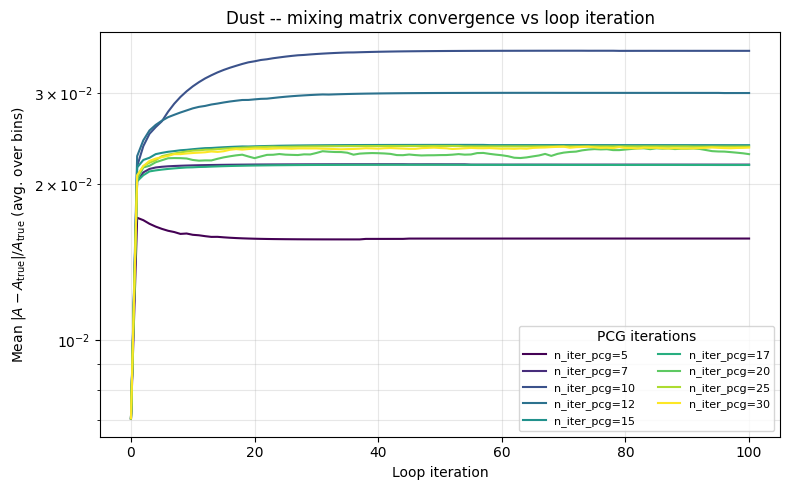

In [ ]:
for ic in free_comps:
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.get_cmap("viridis", len(runs))

    for irun in range(len(runs)):
        resid = np.abs(A_history_stack[irun, :, :, ic] - truth_binned[None, :, ic]) / truth_binned[None, :, ic]
        mean_resid = resid.mean(axis=1)  # mean over bins -> (n_loop_iter,)
        ax.plot(loop_iters, mean_resid, color=cmap(irun), lw=1.5, label=f"n_iter_pcg={n_iters[irun]}")

    ax.set_yscale("log")
    ax.set_xlabel("Loop iteration")
    ax.set_ylabel(r"Mean $|A - A_{\mathrm{true}}| / A_{\mathrm{true}}$ (avg. over bins)")
    ax.legend(fontsize=8, title="PCG iterations", ncol=2)
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()
    plt.show()

In [32]:
import pandas as pd

rel_tol = 0.002  # max relative iteration-to-iteration change to count as "stopped changing"

for ic in free_comps:
    rows = []
    for irun, n_pcg in enumerate(n_iters):
        resid = np.abs(A_history_stack[irun, :, :, ic] - truth_binned[None, :, ic]) / truth_binned[None, :, ic]
        mean_resid = resid.mean(axis=1)
        final_resid = mean_resid[-1]

        step_change = np.abs(np.diff(mean_resid)) / mean_resid[:-1]  # step_change[i]: iteration i -> i+1
        stopped = step_change <= rel_tol

        conv_idx = None
        for i in range(len(stopped) - 1, -1, -1):
            if stopped[i]:
                conv_idx = i
            else:
                break

        rows.append(
            {
                "n_iter_pcg": n_pcg,
                "converged at loop iteration": loop_iters[conv_idx] if conv_idx is not None else "never (still drifting)",
                "final mean residual": final_resid,
            }
        )

    df = pd.DataFrame(rows)
    print(f"--- {comp_names[ic]} ---")
    display(df.style.hide(axis="index").format({"final mean residual": "{:.3e}"}))

--- Dust ---


n_iter_pcg,converged at loop iteration,final mean residual
5,38,1.570e-02
7,6,2.180e-02
10,29,3.614e-02
12,27,2.996e-02
15,12,2.377e-02
17,8,2.176e-02
20,never (still drifting),2.284e-02
25,54,2.362e-02
30,83,2.351e-02
